## 🧠 Business Problem
Predict Units Sold per (Store, Product, Date)                                                                                                               
→ Optimize inventory replenishment                                                                                                                          
→ Reduce stockouts and overstock

### What is the problem with our retail business — Overstokke or Stokkout?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/retail_store_inventory_cleaned.csv')

In [41]:
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,...,lag_1,lag_7,lag_14,lag_30,lag_60,price_diff,discount_effect,price_ratio,remaining_stock,Revenue
0,2022-03-02,S001,P0001,Groceries,South,216,93,120,58.52,15,...,28.0,129.0,373.0,200.0,127.0,-0.40,877.8,0.993211,-27,5442.36
1,2022-03-03,S001,P0001,Toys,South,304,36,44,14.01,0,...,93.0,177.0,31.0,279.0,81.0,1.14,0.0,1.088577,-8,504.36
2,2022-03-04,S001,P0001,Toys,South,338,284,43,33.06,15,...,36.0,214.0,27.0,38.0,5.0,-1.41,495.9,0.959095,241,9389.04
3,2022-03-05,S001,P0001,Furniture,East,496,282,167,27.67,10,...,284.0,106.0,27.0,71.0,58.0,-0.98,276.7,0.965794,115,7802.94
4,2022-03-06,S001,P0001,Electronics,South,463,192,54,62.37,10,...,282.0,68.0,166.0,25.0,147.0,-2.27,623.7,0.964882,138,11975.04


Unique product IDs: ['P0001' 'P0002' 'P0003' 'P0004' 'P0005' 'P0006' 'P0007' 'P0008' 'P0009'
 'P0010' 'P0011' 'P0012' 'P0013' 'P0014' 'P0015' 'P0016' 'P0017' 'P0018'
 'P0019' 'P0020']


In [5]:
df.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'price', 'discount',
       'weather_condition', 'holiday/promotion', 'competitor_pricing',
       'seasonality', 'year', 'month', 'weekday', 'weekofyear', 'is_weekend',
       'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'lag_1', 'lag_7',
       'lag_14', 'lag_30', 'lag_60', 'price_diff', 'discount_effect',
       'price_ratio'],
      dtype='object')

In [6]:
stock_order=df.groupby(['category'])["units_ordered"].sum().reset_index()
stock_order

,category,units_ordered
0,Clothing,1483909
1,Electronics,1459141
2,Furniture,1481776
3,Groceries,1476236
4,Toys,1479074


In [8]:
stock_sold=df.groupby("category")["units_sold"].sum().reset_index()
stock_sold

,category,units_sold
0,Clothing,1828698
1,Electronics,1794961
2,Furniture,1859493
3,Groceries,1841706
4,Toys,1825627


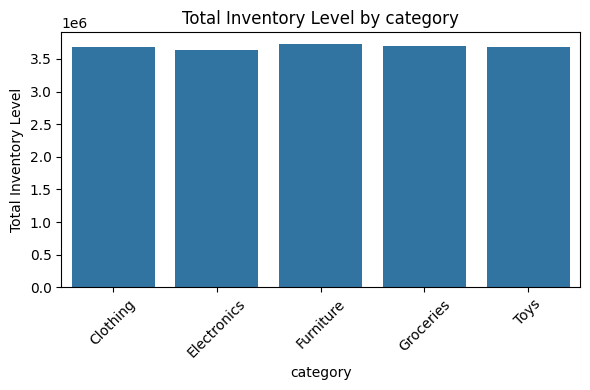

In [10]:
total_stock=df.groupby("category")["inventory_level"].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='category', y='inventory_level', data=total_stock)
plt.title('Total Inventory Level by category')
plt.xlabel('category')
plt.ylabel('Total Inventory Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df["remaining_stock"]=(df["units_sold"]-df["units_ordered"])
remaining_stock=df.groupby("category")["remaining_stock"].sum().reset_index()
remaining_stock

,category,remaining_stock
0,Clothing,344789
1,Electronics,335820
2,Furniture,377717
3,Groceries,365470
4,Toys,346553


### We have excess inventory in stock.

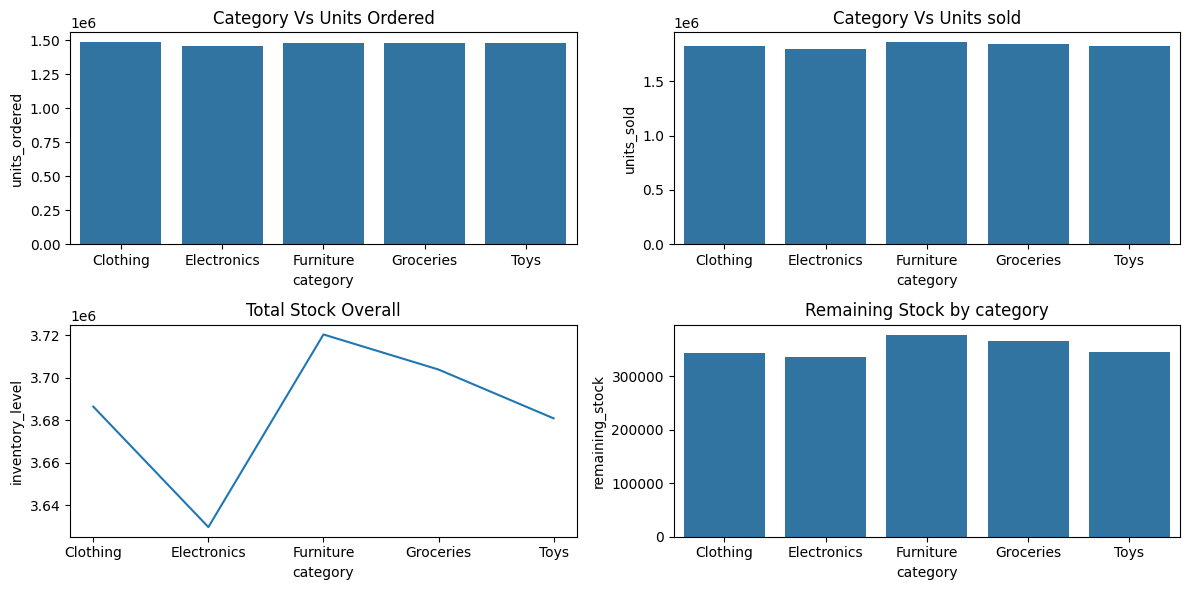

In [13]:
plt.figure(figsize=(12,6))
# Category Vs Units order graph

plt.subplot(2,2,1)
sns.barplot(x='category', y='units_ordered', data=stock_order)
plt.title("Category Vs Units Ordered")
plt.tight_layout()


# Category Vs Units sold graph
plt.subplot(2,2,2)
sns.barplot(x='category',y='units_sold',data=stock_sold)
plt.title("Category Vs Units sold")
plt.tight_layout()

# Total Stock Graph
plt.subplot(2,2,3)
sns.lineplot(x='category',y="inventory_level",data=total_stock)
plt.title("Total Stock Overall")
plt.tight_layout()

# Remaining stock
plt.subplot(2,2,4)

sns.barplot(x="category",y='remaining_stock',data=remaining_stock)
plt.title("Remaining Stock by category")
plt.tight_layout()

### Furniture has the highest demand, while electronics have the lowest sales. We also have a large amount of furniture stock available. Our top-selling category is furniture, followed by clothing, groceries, and toys, with electronics ranking last

In [15]:
# Which products generate the highest revenue for us?

df["Revenue"]=df["units_sold"]*df['price']
revenue_count=df.groupby("category")["Revenue"].sum().reset_index()
revenue_count

,category,Revenue
0,Clothing,1.001800e+08
1,Electronics,9.934714e+07
2,Furniture,1.024386e+08
3,Groceries,1.023970e+08
4,Toys,1.005373e+08


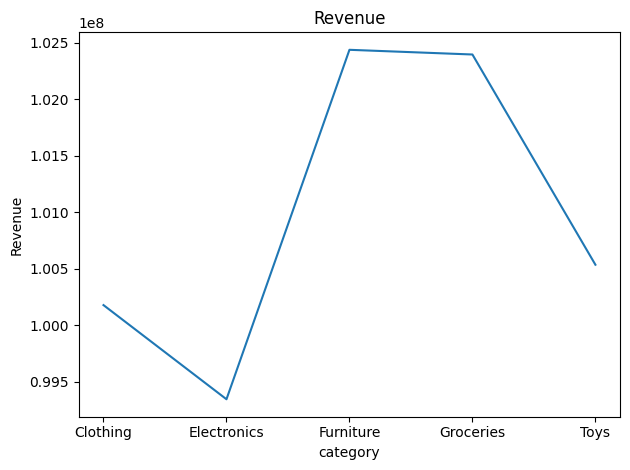

In [16]:
sns.lineplot(x="category",y="Revenue",data=revenue_count)
plt.title("Revenue")
plt.tight_layout()
plt.show()

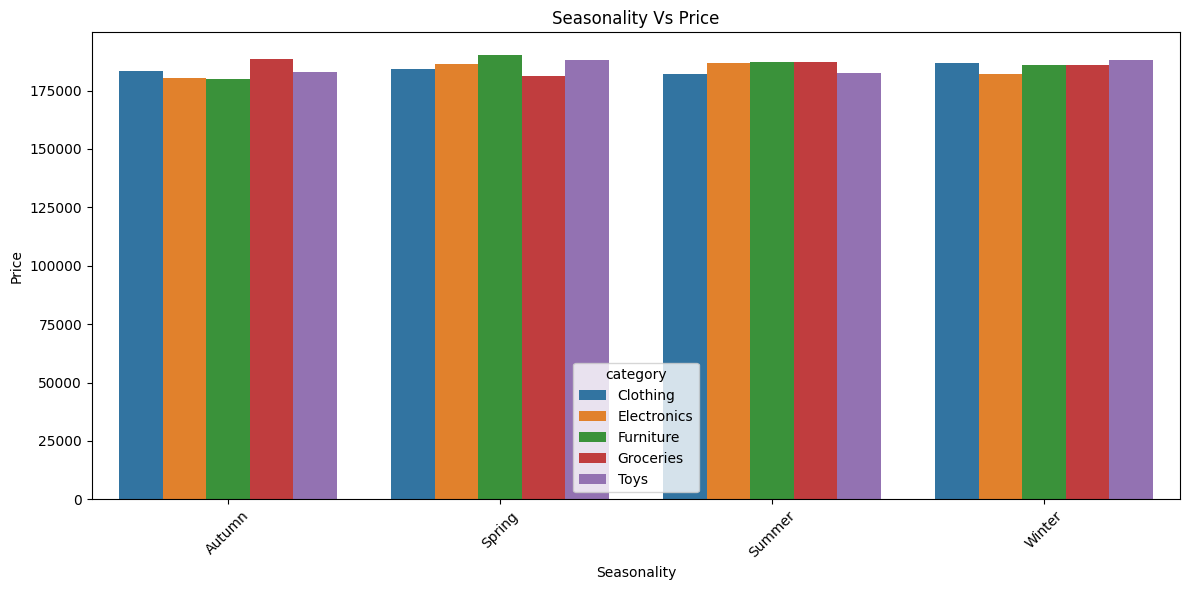

In [18]:
# Do seasonal trends affect our sales?
seasonal_sale=df.groupby(["seasonality","category"])["price"].sum().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x="seasonality",y="price",hue="category",data=seasonal_sale)
plt.title("Seasonality Vs Price")
plt.xlabel("Seasonality")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Furniture is the top-performing category, generating the most revenue.- Groceries come second, showing consistent performance and steady demand
Clothing and Toys are in the middle range, with very close revenues. Electronics has the lowest revenue among all categories

---------------------------------------------------------------

### Sales across all categories remain relatively stable over time, with Furniture and Groceries consistently performing slightly better. Electronics show comparatively lower sales, indicating a potential area for improvement. Seasonal impact appears minimal, suggesting steady demand throughout the period

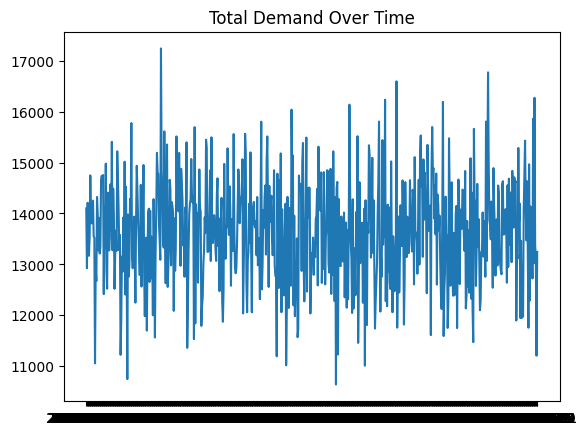

In [19]:
# Overall Demand Trend
daily_sales = df.groupby('date')['units_sold'].sum()

plt.plot(daily_sales)
plt.title("Total Demand Over Time")
plt.show()

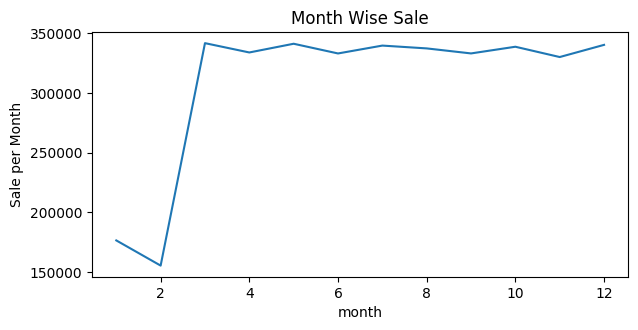

In [27]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.lineplot(x="month",y="price",data=monthly_sale)
plt.title("Month Wise Sale")
plt.ylabel("Sale per Month")
plt.tight_layout()

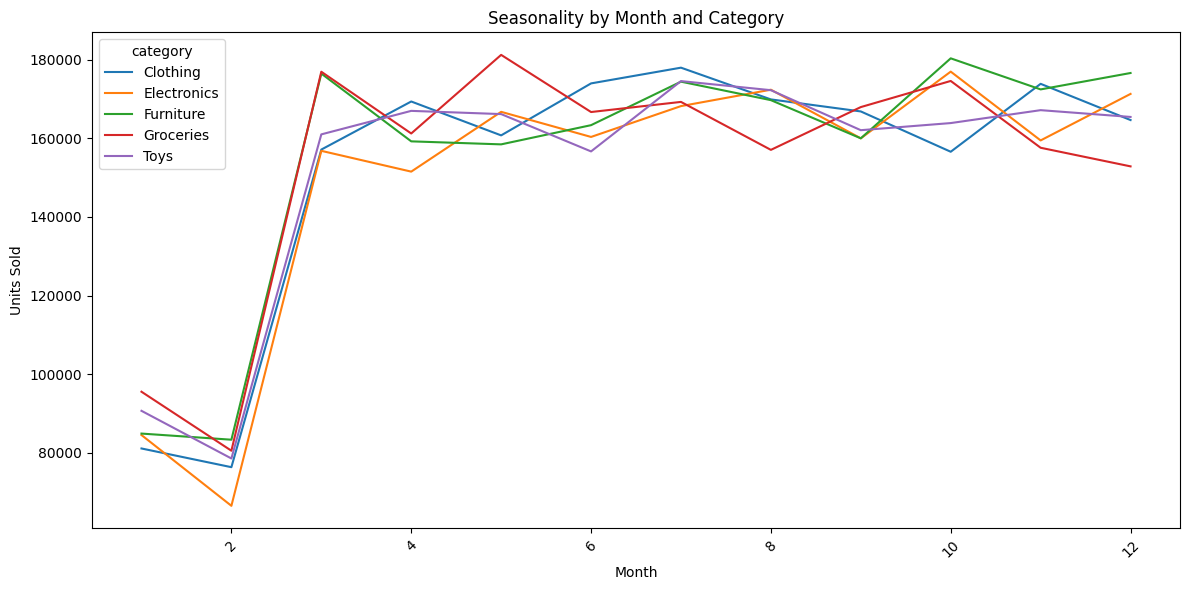

In [21]:
# Seasonality Trends by month and weekday and demand by month and weekday and category

seasonality_month = df.groupby(['month', 'category'])['units_sold'].sum().reset_index()
seasonality_weekday = df.groupby(['weekday', 'category'])['units_sold'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x='month', y='units_sold', hue='category', data=seasonality_month)
plt.title("Seasonality by Month and Category")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

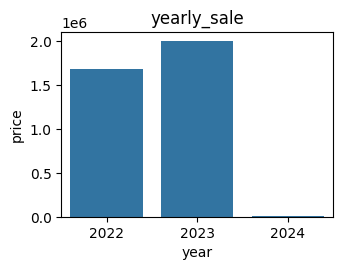

In [29]:
# Yearly Sale
plt.subplot(2,2,2)
sns.barplot(x="year",data=yearly_sale,y="price")
plt.title("yearly_sale")
plt.tight_layout()

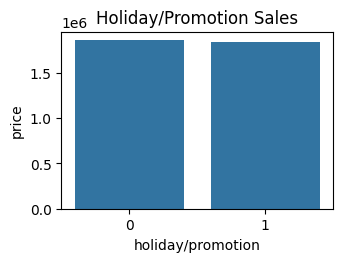

In [31]:
# Are sales higher on weekends or holidays?
plt.subplot(2,2,3)
sns.barplot(x="holiday/promotion", y="price", data=holidays_sale)
plt.title("Holiday/Promotion Sales")
plt.tight_layout()

In [25]:
# What do the daily, weekly, or monthly sales trends show?

monthly_sale=df.groupby(["month"])["price"].sum().reset_index()
monthly_sale

yearly_sale=df.groupby("year")["price"].sum().reset_index()
yearly_sale

holidays_sale=df.groupby("holiday/promotion")["price"].sum().reset_index()
holidays_sale

,holiday/promotion,price
0,0,1859109.97
1,1,1841205.75


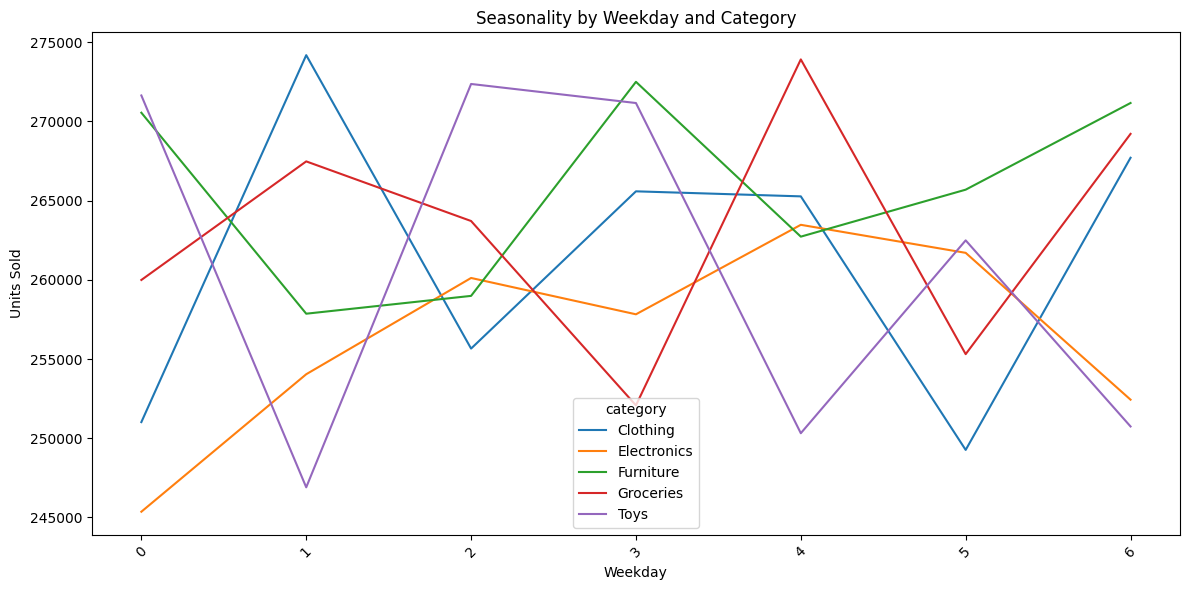

In [22]:
# Seasonality by Weekday and Category
plt.figure(figsize=(12,6))
sns.lineplot(x='weekday', y='units_sold', hue='category', data=seasonality_weekday)
plt.title("Seasonality by Weekday and Category")
plt.xlabel("Weekday")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sales remain consistent on a monthly and yearly basis, showing stable business performance. However, a noticeable increase in sales is observed during holidays, highlighting the importance of seasonal events in driving revenue

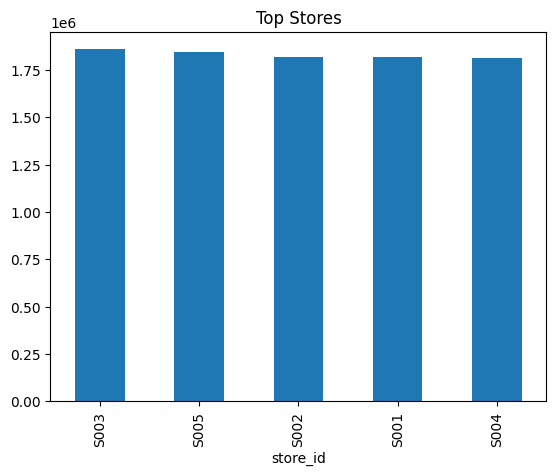

In [32]:
# Store Performance
store_perf = df.groupby('store_id')['units_sold'].sum().sort_values(ascending=False)

store_perf.head(10).plot(kind='bar')
plt.title("Top Stores")
plt.show()

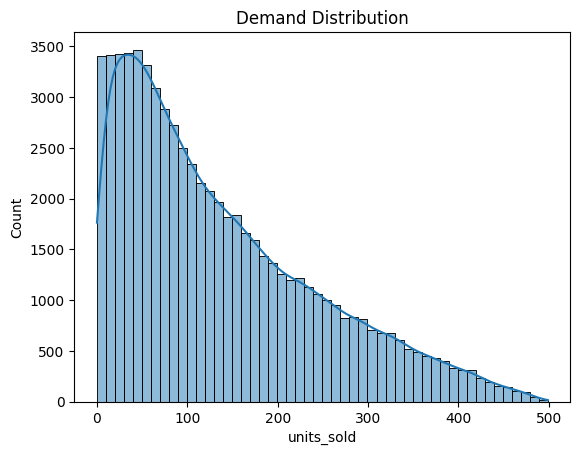

In [33]:
# Product Distribution
sns.histplot(df['units_sold'], bins=50, kde=True)
plt.title("Demand Distribution")
plt.show()

#### right-skewed distribution

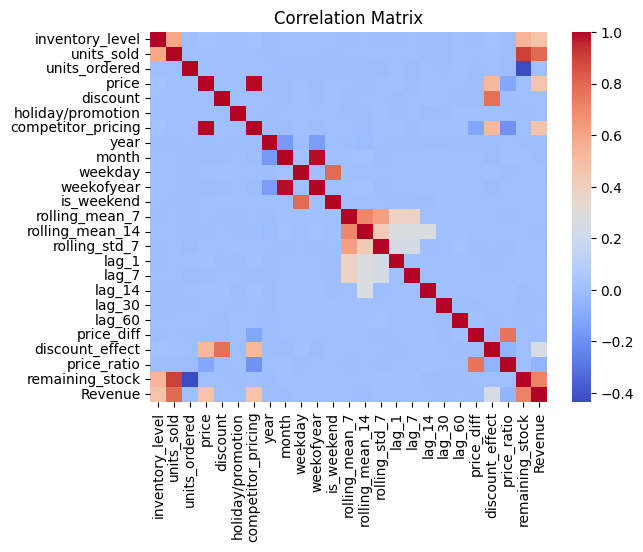

In [34]:
# Correlation
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

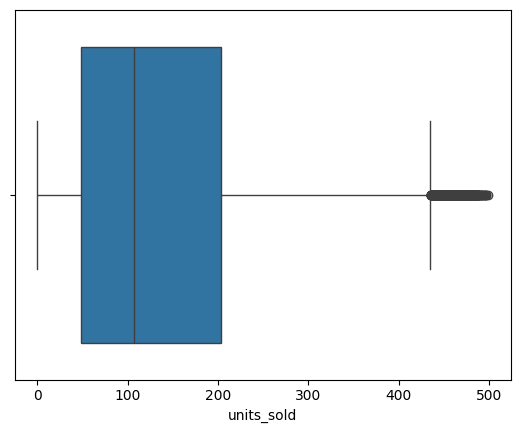

In [35]:
# Outliers
sns.boxplot(x=df['units_sold'])
plt.show()

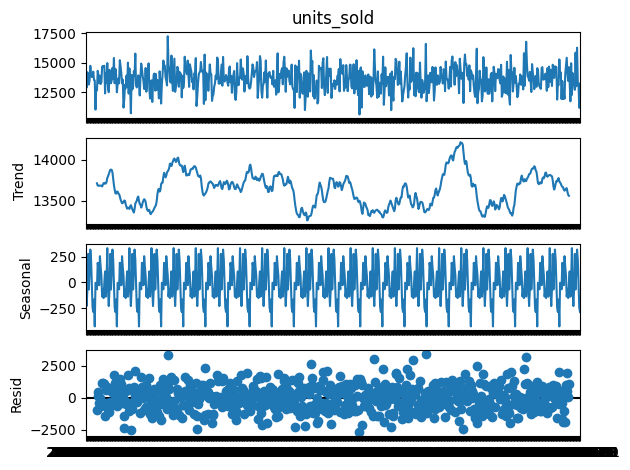

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose

# TIME SERIES DECOMPOSITION
decomp = seasonal_decompose(daily_sales, model='additive', period=30)

decomp.plot()
plt.show()

In [40]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])



ADF Statistic: -25.29557309372423
p-value: 0.0
